In [1]:
import biosteam as bst
import numpy as np
import pyrolysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "STIXGeneral",
    "text.latex.preamble": r"\usepackage[utf8]{inputenc}\usepackage{amsmath}",
    "figure.figsize": [12, 4],  # ancho, Largo  
    "xtick.labelsize": 13,  # tamaño ticks en eje x
    "ytick.labelsize": 13   # tamaño ticks en eje y
})


In [2]:
bst.nbtutorial()  # Clean warnings
bst.Stream.display_units.flow = 'kg/hr' # Fix units flow
bst.settings.define_impact_indicator(key='GWP 100yr', units='kg*CO2e')
bst.settings.set_electricity_CF('GWP 100yr', 0.36, basis='kWhr', units='kg*CO2e')

settings = pyrolysis.load_chemicals()
MW_list= settings.chemicals.MW
context_sys, tea, NPV , IRR_val, Fedi_val, GWP = pyrolysis.create_system(processing_capacity=6250,  x = 55,
                                                           y = 3.5, settings = settings) 
print(GWP)


18571619.941874996
1237500.0
13781167.767684614
2936957.4401592617
{'energy_kgCO2e_per_kg': {'activatedcarbon': 0.6280698416748997, 'metals': 0.0, 'diesel': 1.0589943021351105, 'LFO': 1.0299957551977652}, 'revenue_kgCO2e_per_kg': {'activatedcarbon': 1.2606412671616645, 'metals': 0.08536342294780414, 'diesel': 0.4097084118275409, 'LFO': 0.15127695205939973}, 'mass_kgCO2e_per_kg': {'activatedcarbon': 0.0381508561028881, 'metals': 0.5725439999999999, 'diesel': 0.051412421062125964, 'LFO': 0.24124394528562831}}


In [16]:
context_sys.heat_utilities

[<natural_gas: 0 kJ/hr, 0 kmol/hr, 0 USD/hr>,
 <ethylene: -1.59e+06 kJ/hr, 119 kmol/hr, 52.8 USD/hr>,
 <cooling_water: -1.76e+06 kJ/hr, 1.2e+03 kmol/hr, 0.588 USD/hr>,
 <chilled_water: -7.69e+06 kJ/hr, 5.1e+03 kmol/hr, 38.4 USD/hr>,
 <medium_pressure_steam: 0 kJ/hr, 0 kmol/hr, 0 USD/hr>]

In [9]:
context_sys.get_property_allocated_impact(key='GWP 100yr', name="revenue", basis="USD")

0.360183219189047

System: example
Highest convergence error among components in recycle
stream NapthaPox-1 after 3 loops:
- flow rate   2.79e-01 kmol/hr (0.9%)
- temperature 0.00e+00 K (0%)
ins...
[0] s1  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow: 0
[1] boiler_makeup_water  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): oxidane  187
[2] natural_gas  
    phase: 'g', T: 288.71 K, P: 101560 Pa
    flow: 0
[3] waste1  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): oxidane    17.4
                  1305-62-0  17.9
[4] waste2  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): Ash  0.0133
[5] -  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): molecular nitrogen  5.88e+03
                  molecular oxygen    1.56e+03
[6] Tyre_Stream  
    phase: 's', T: 293.15 K, P: 101325 Pa
    flow (kg/hr): Tyre  6.51e+03
[7] air  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): molecular nitrogen  3.26e+03
                  molecular oxygen    867
[

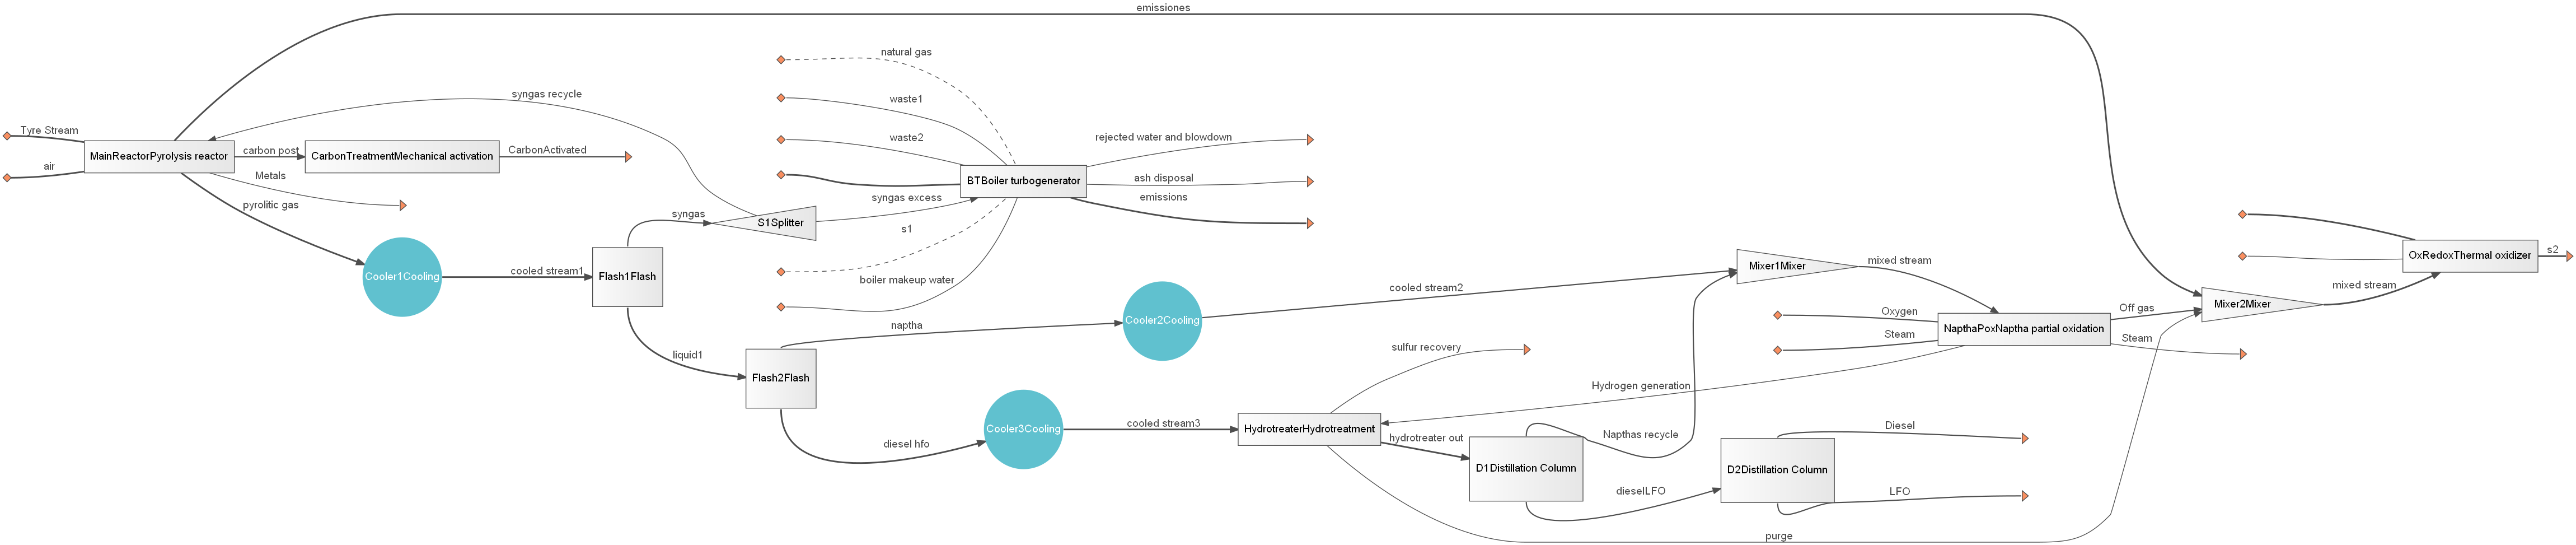

In [3]:
context_sys.show()
context_sys.diagram(kind=1, format='png', label = True)

In [14]:
from biosteam import report
report.lca_inventory_table(systems=[context_sys],
                           keys= ['GWP 100yr'],
                           items=[bst.F.CarbonActivated])

Inventory [kg/yr]
Inputs            Oxygen                         3.94e+06
                  Tyre Stream                    5.16e+07
Outputs           CarbonActivated                1.86e+07
                  Diesel                         1.38e+07
                  LFO                            2.94e+06
                  Metals                         1.24e+06
                  Electricity [kWhr/yr]          5.85e+05
direct_emissions1                                 3.4e+06
direct_emissions2                                2.55e+07

# Uncertainty analysis

In [ ]:
# Lets evalute only at one processing capacity
procesing_capacities = [6250, 4166, 2500]
n_samples = [5000,1000,1000]
for i, pc in enumerate(procesing_capacities):  
    file_ps = r'test_scenario_run{val}.csv'.format(val = i +1) 
    file_corr = r'test_scenario_run{val}_corr.csv'.format(val = i+1)
    pyrolysis.run_montecarlo(pc, file_ps, file_corr,
                        settings , N_samples= n_samples[i] )

[100] Elapsed time: 932 sec
[200] Elapsed time: 1786 sec
[300] Elapsed time: 2607 sec
[400] Elapsed time: 3424 sec
[500] Elapsed time: 4402 sec
[600] Elapsed time: 5272 sec
[700] Elapsed time: 6200 sec
[800] Elapsed time: 7070 sec
[900] Elapsed time: 8013 sec
[1000] Elapsed time: 8781 sec
[1100] Elapsed time: 9724 sec
[1200] Elapsed time: 10710 sec
[1300] Elapsed time: 11554 sec
[1400] Elapsed time: 12524 sec
[1500] Elapsed time: 13318 sec
[1600] Elapsed time: 14104 sec
[1700] Elapsed time: 15023 sec
[1800] Elapsed time: 15979 sec
[1900] Elapsed time: 16808 sec
[2000] Elapsed time: 17845 sec
[2100] Elapsed time: 18965 sec
[2200] Elapsed time: 19948 sec
[2300] Elapsed time: 20860 sec
[2400] Elapsed time: 21680 sec
[2500] Elapsed time: 22621 sec
[2600] Elapsed time: 23538 sec
[2700] Elapsed time: 24528 sec
[2800] Elapsed time: 25440 sec
[2900] Elapsed time: 26362 sec
[3000] Elapsed time: 27319 sec
[3100] Elapsed time: 28149 sec
[3200] Elapsed time: 29193 sec
[3300] Elapsed time: 30114 se

# Plot uncertainty for products

c:\Users\gabo1\OneDrive\Desktop\Doctorado\2. Trabajos doctorales\11. Pyrolisis\pyrolysis\plots.py:1327: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


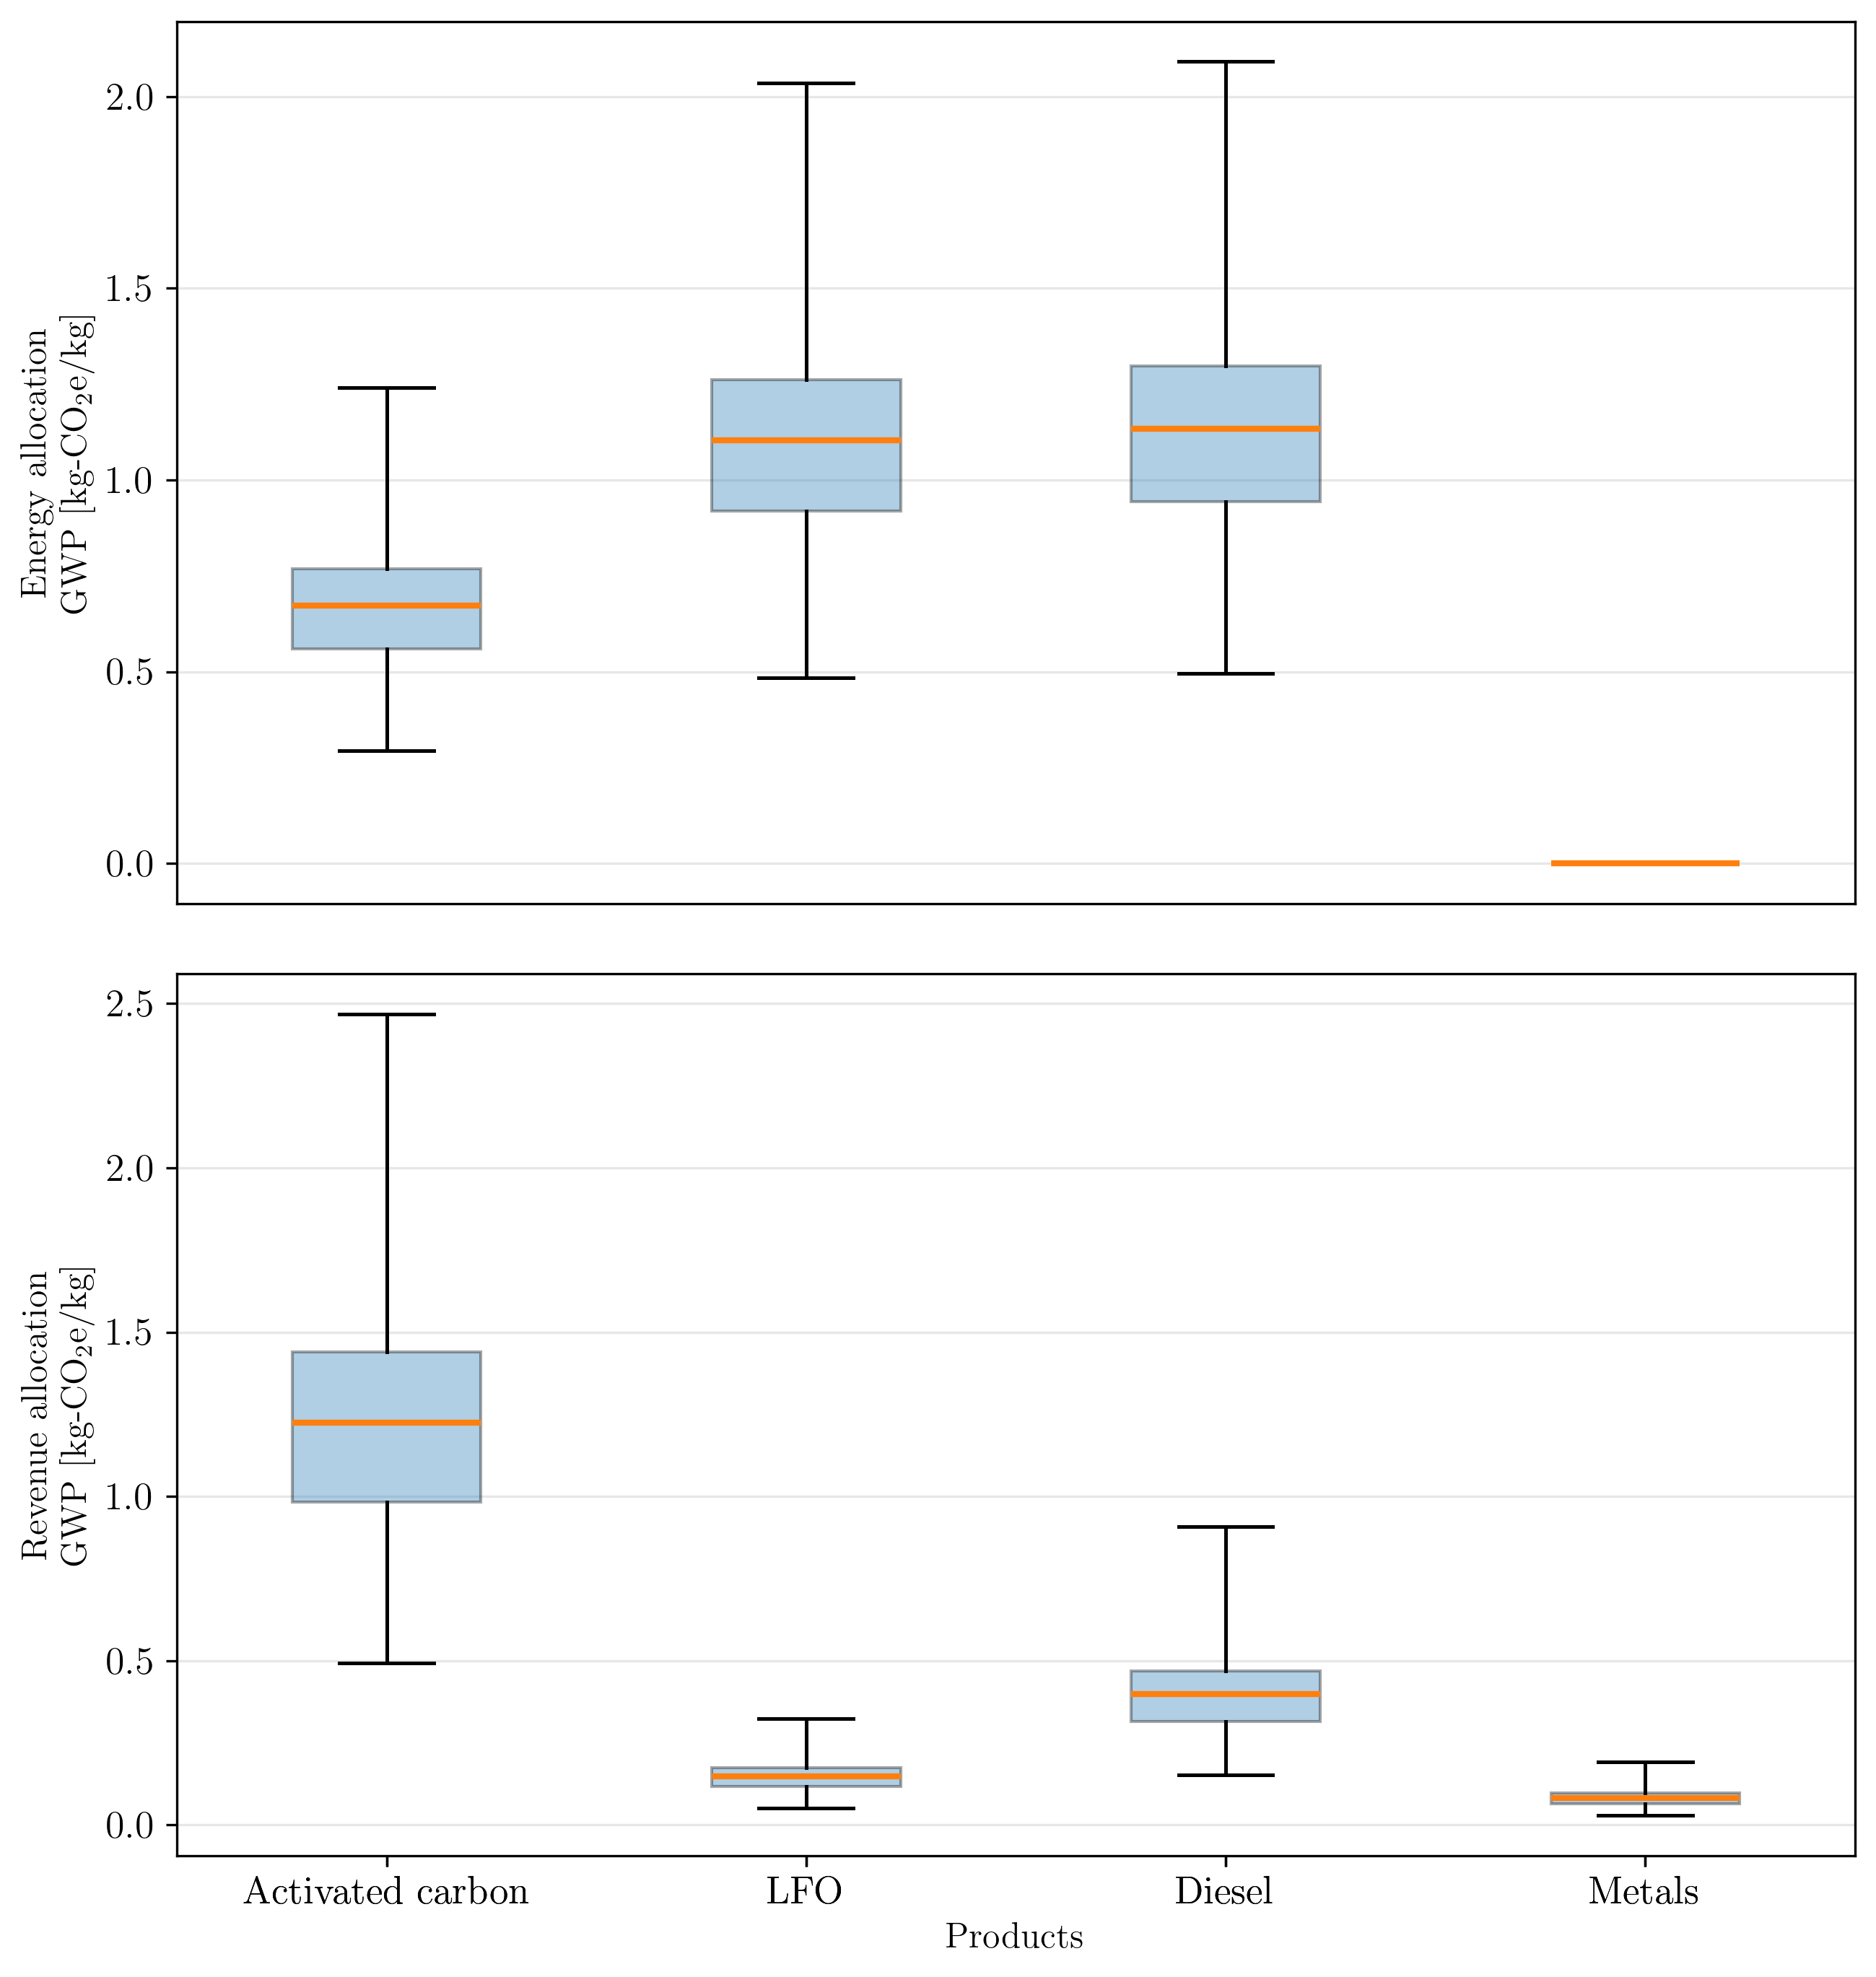


SUMMARY STATISTICS FOR GWP RESULTS

ENERGY ALLOCATION
----------------------------------------------------------------------
Activated carbon     mean = 0.6727 | P5 = 0.4394 | P95 = 0.9638 | min = 0.2937 | max = 1.2407 | n = 5000
LFO                  mean = 1.1043 | P5 = 0.7212 | P95 = 1.5816 | min = 0.4836 | max = 2.0355 | n = 5000
Diesel               mean = 1.1343 | P5 = 0.7407 | P95 = 1.6260 | min = 0.4962 | max = 2.0914 | n = 5000
Metals               mean = 0.0000 | P5 = 0.0000 | P95 = 0.0000 | min = 0.0000 | max = 0.0000 | n = 5000

REVENUE ALLOCATION
----------------------------------------------------------------------
Activated carbon     mean = 1.2240 | P5 = 0.7395 | P95 = 1.8092 | min = 0.4932 | max = 2.4681 | n = 5000
LFO                  mean = 0.1477 | P5 = 0.0866 | P95 = 0.2255 | min = 0.0507 | max = 0.3239 | n = 5000
Diesel               mean = 0.3995 | P5 = 0.2378 | P95 = 0.6036 | min = 0.1522 | max = 0.9087 | n = 5000
Metals               mean = 0.0833 | P5 = 0.0487

{'energy': {'Activated carbon': {'mean': 0.6726756870733305,
   'p5': 0.439378554683807,
   'p95': 0.9638361199143649,
   'min': 0.293657294376356,
   'max': 1.240709715507469,
   'n': 5000},
  'LFO': {'mean': 1.1042691964700775,
   'p5': 0.721161526584134,
   'p95': 1.5815667650579792,
   'min': 0.4835922384105093,
   'max': 2.0354734492006634,
   'n': 5000},
  'Diesel': {'mean': 1.1342648400657596,
   'p5': 0.7407110013342016,
   'p95': 1.6259976590738323,
   'min': 0.4962038039422154,
   'max': 2.0913746816618835,
   'n': 5000},
  'Metals': {'mean': 0.0,
   'p5': 0.0,
   'p95': 0.0,
   'min': 0.0,
   'max': 0.0,
   'n': 5000}},
 'revenue': {'Activated carbon': {'mean': 1.2239531170114613,
   'p5': 0.7395478189544996,
   'p95': 1.8091707429711887,
   'min': 0.4931769371082194,
   'max': 2.4680891341606657,
   'n': 5000},
  'LFO': {'mean': 0.14770699580222016,
   'p5': 0.0866498629933708,
   'p95': 0.2254765313694497,
   'min': 0.050691317471419,
   'max': 0.3239076057290008,
   'n': 

In [1]:
import pyrolysis
pyrolysis.plot_gwp(file_df='test_scenario_run1.csv', file='FigureS1.eps')

# Plot the correlation at 6250 kg/hr 

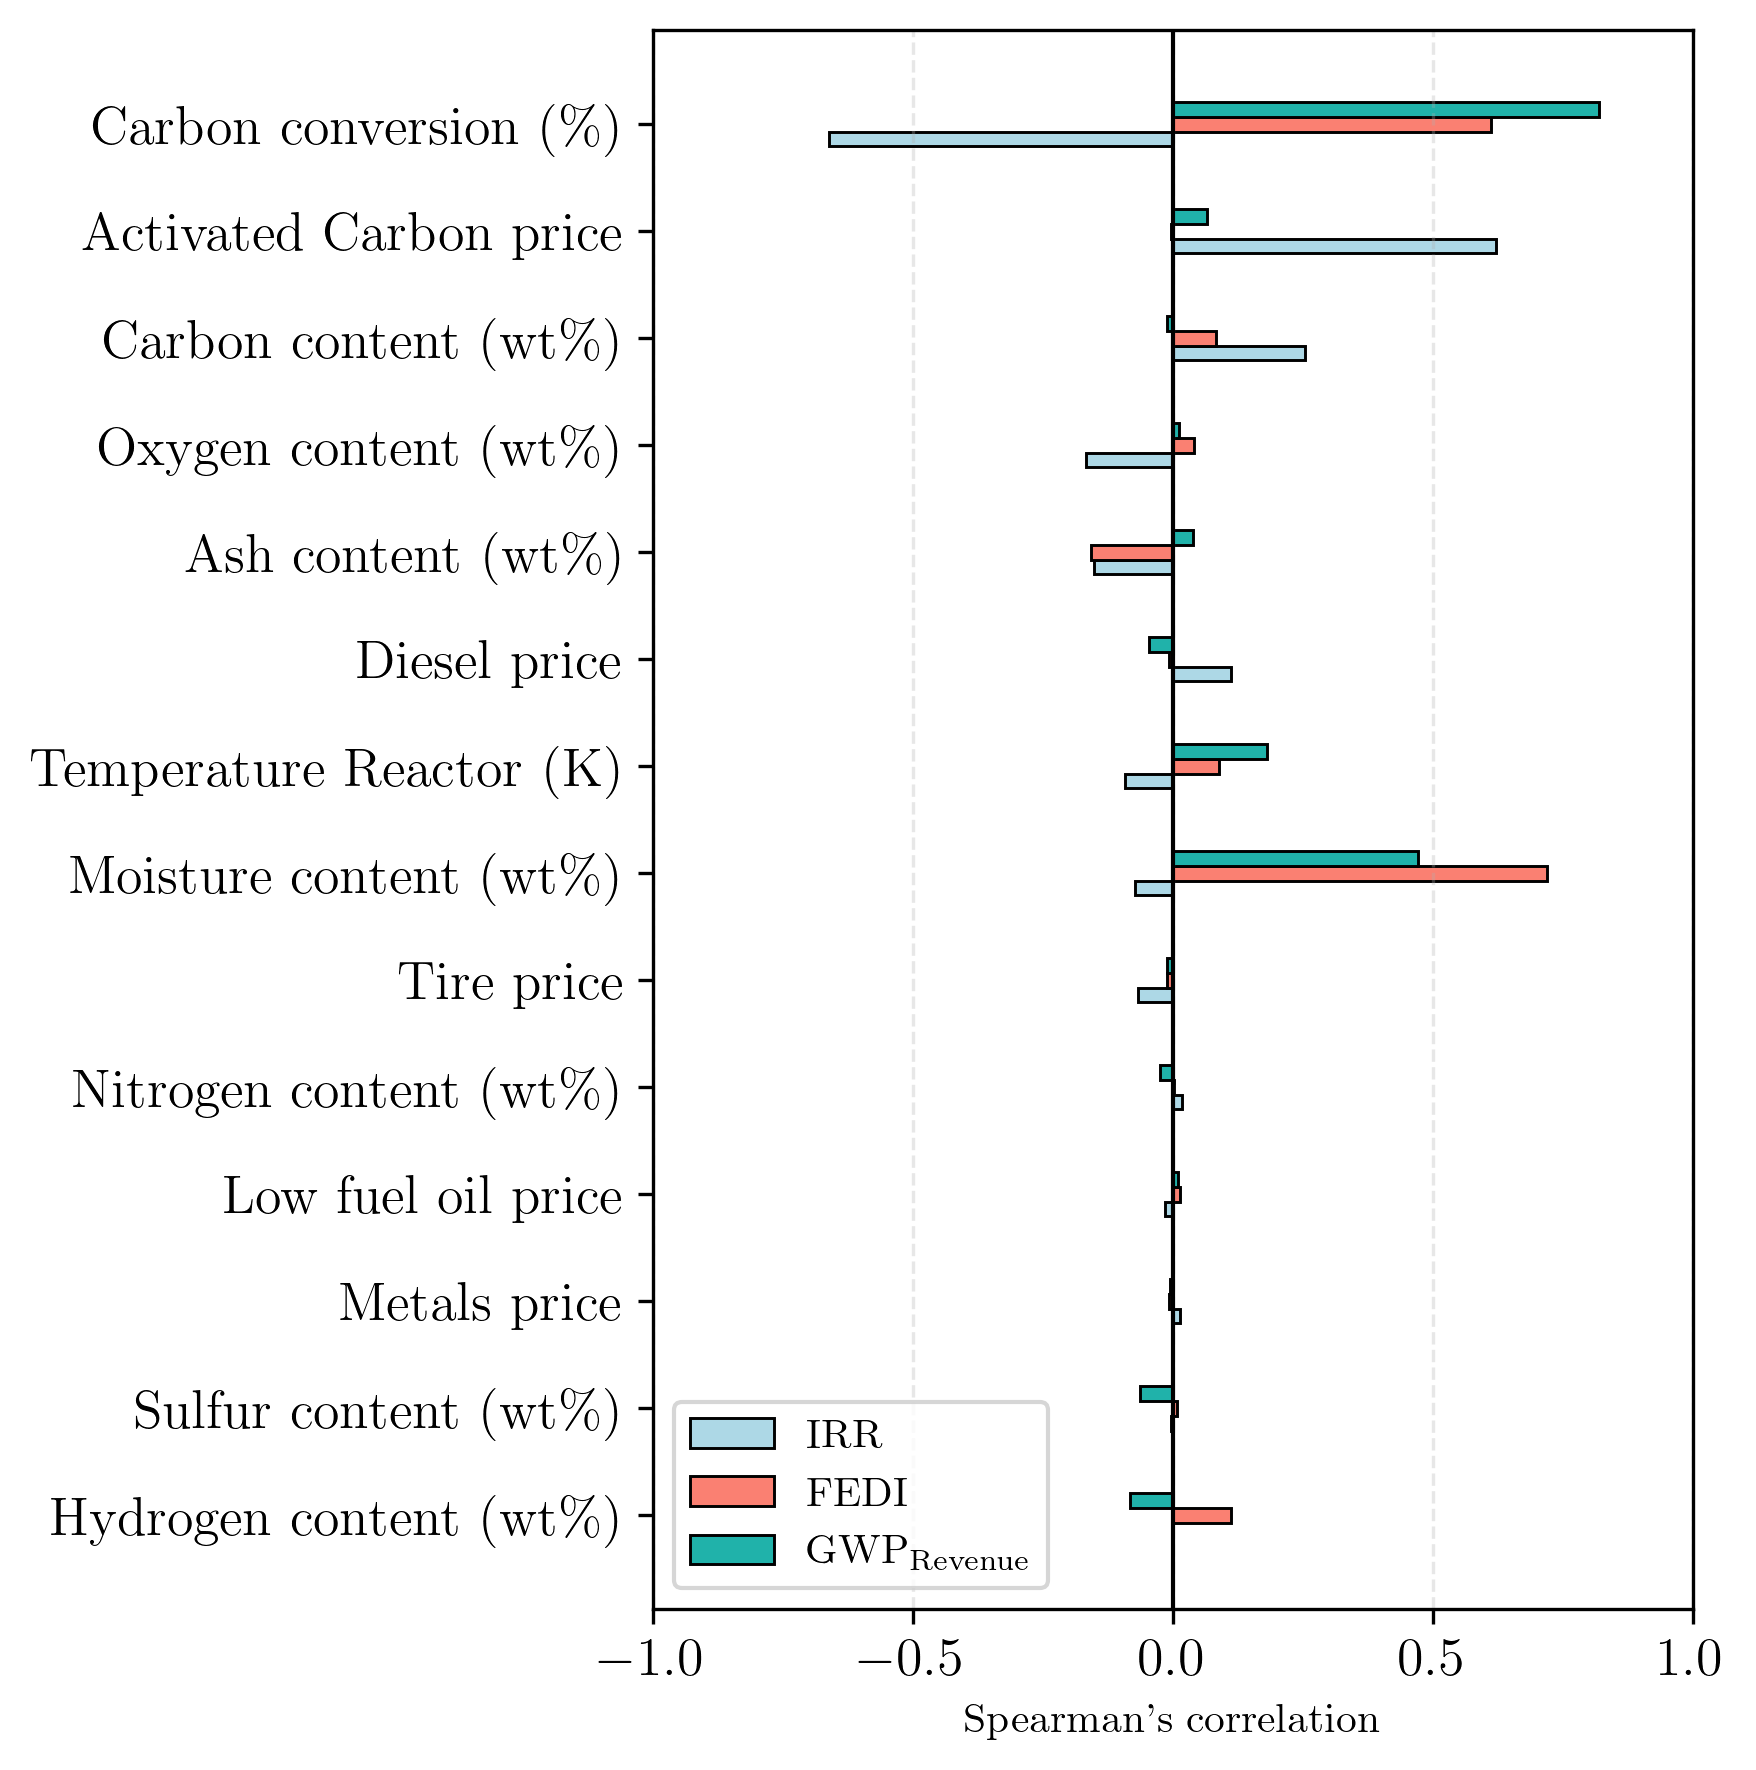

In [8]:
pyrolysis.plot_spearman(file_df = 'test_scenario_run1_corr.csv' , file = 'Figure8.eps' )


# Vary carbon yield and carbon activated price


In [5]:
# This command will save all the values in a numpy array 
pyrolysis.titer_carbonyield_price('carbon_yield_priceAC_test.npz', n = 10)
# aproximated time : 

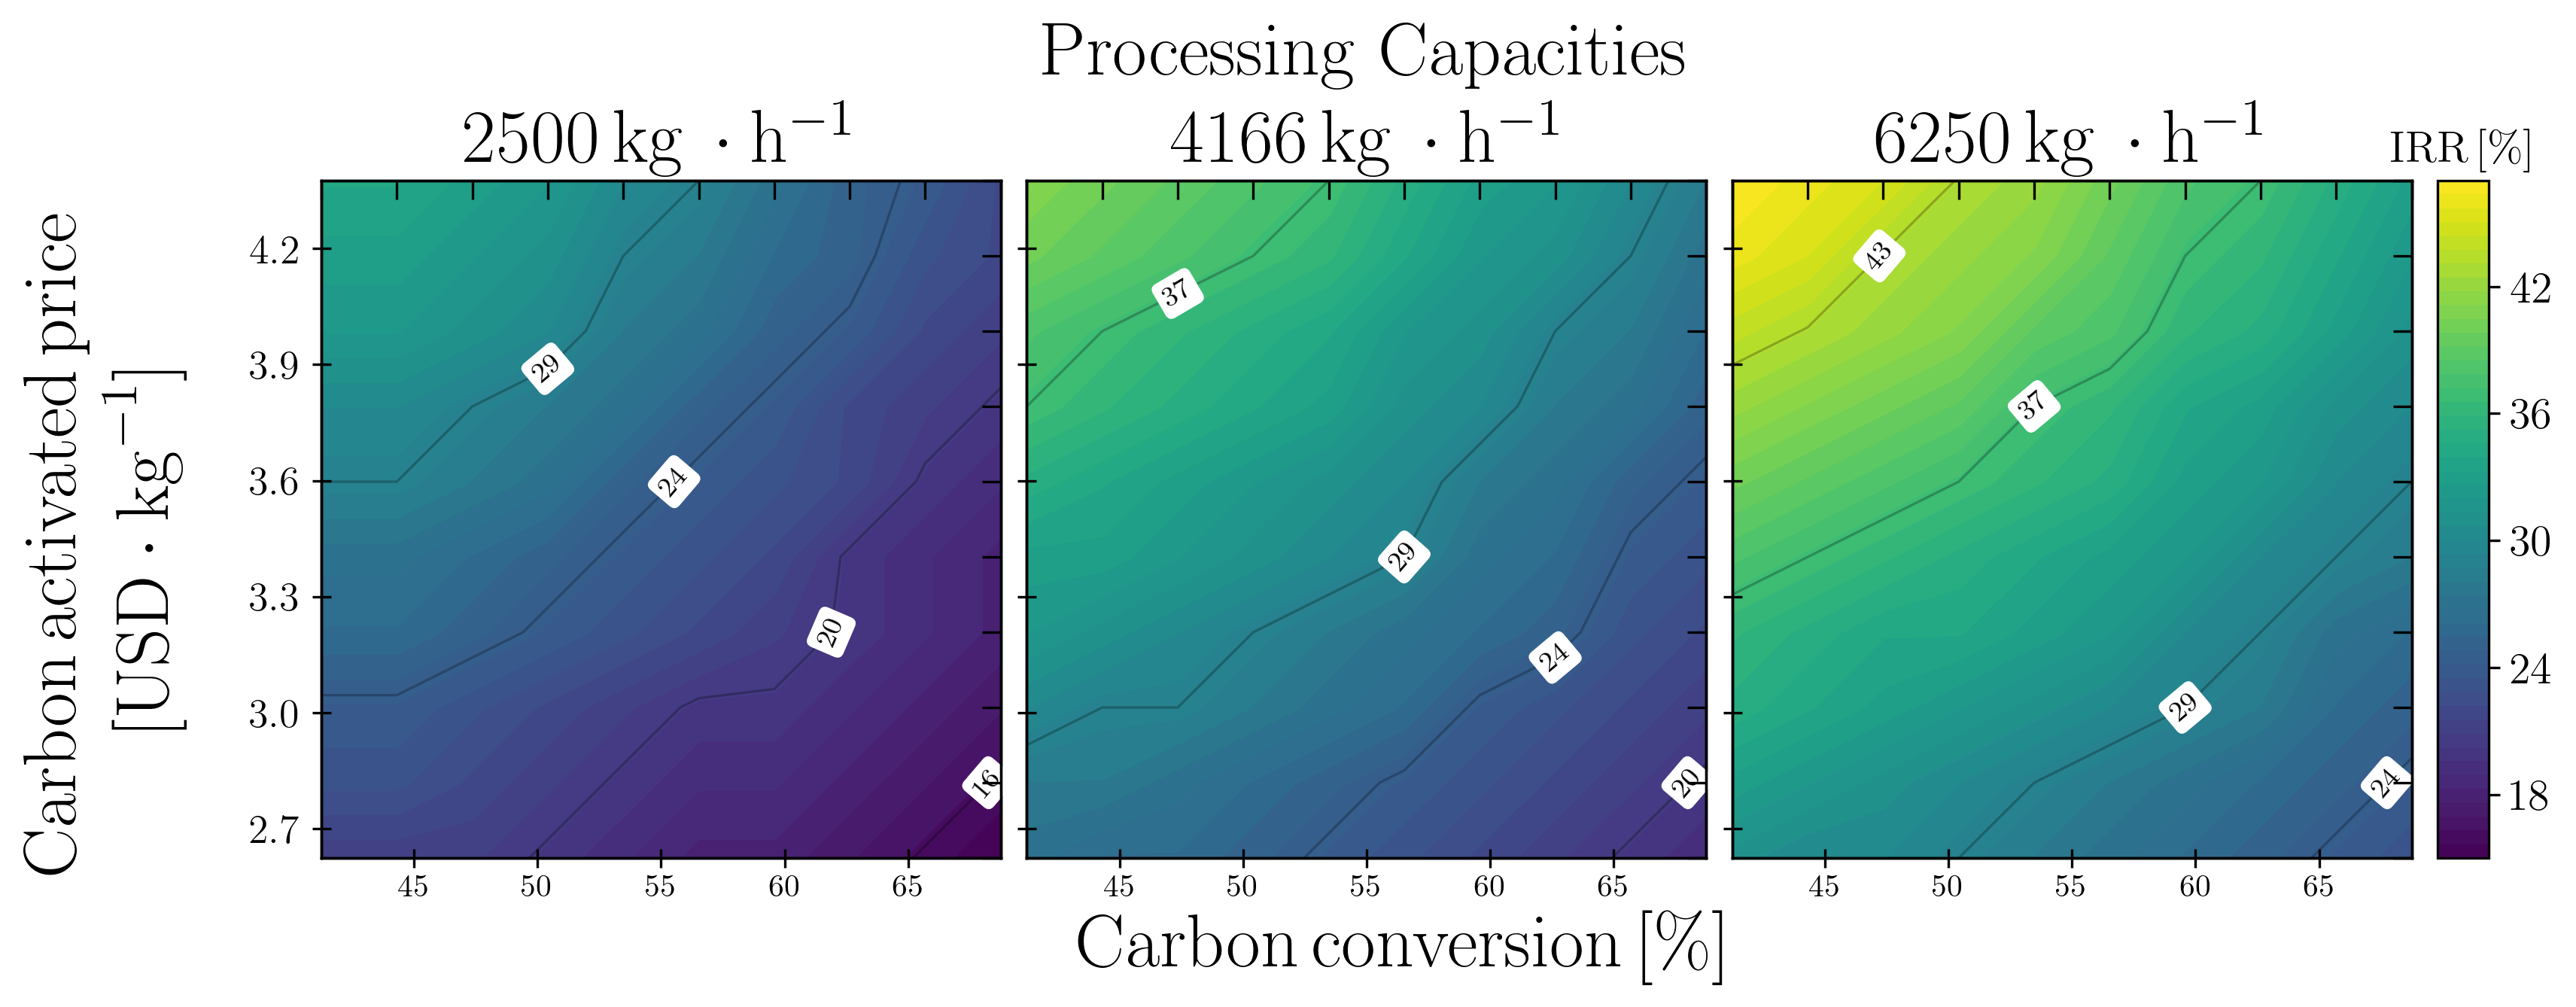

In [6]:
pyrolysis.plot_titer_carbonyield_price('carbon_yield_priceAC_test.npz')

# Vary carbon yield and diesel price

In [7]:
# This command will save all the values in a numpy array 
pyrolysis.titer_carbonyield_dieselprice('carbon_yield_dieselprice_test.npz', n = 10)
# 203 minutos

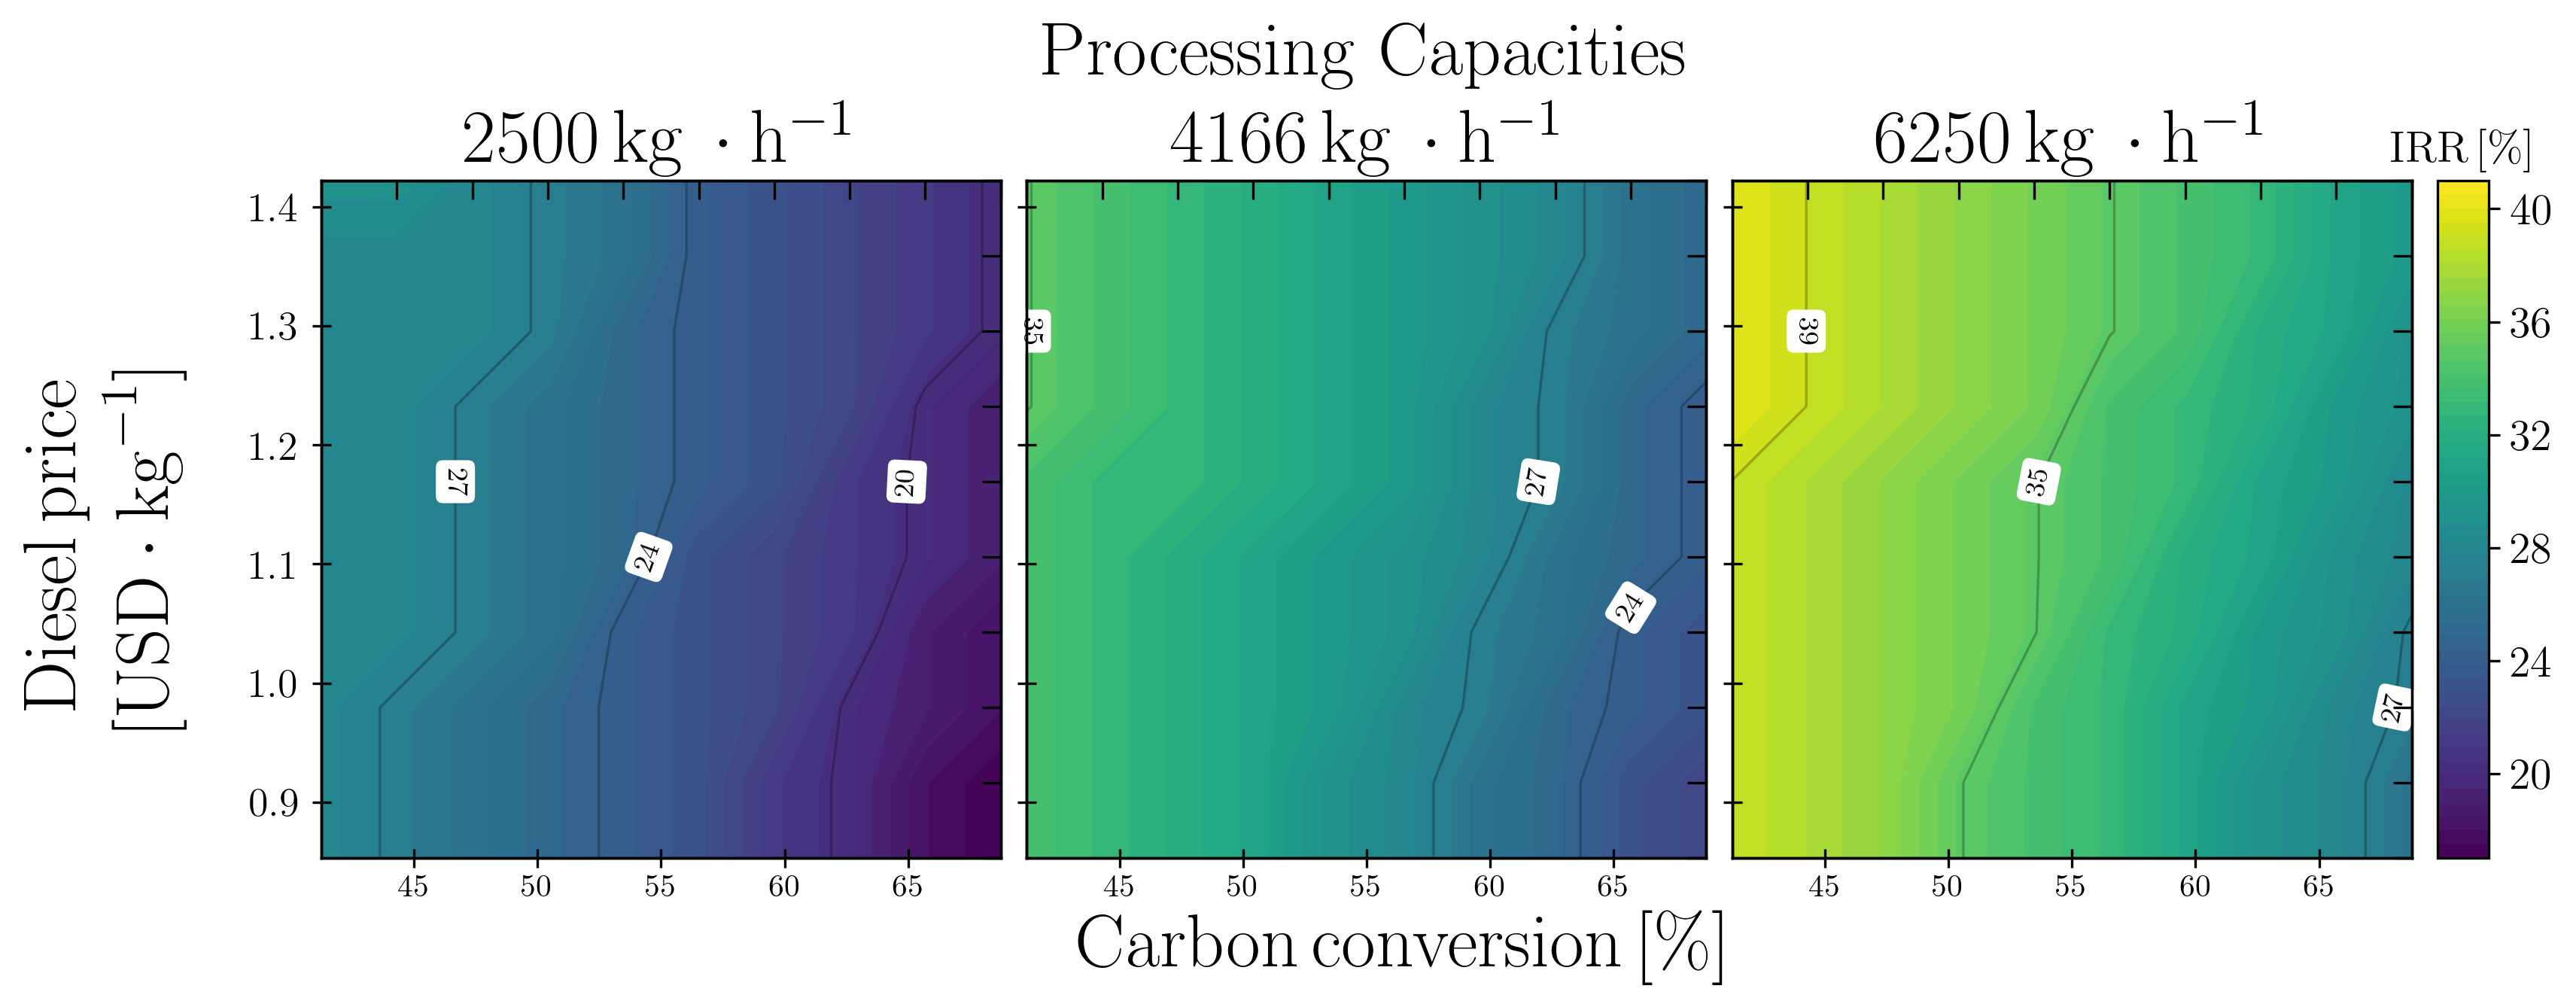

In [5]:
import pyrolysis
pyrolysis.plot_titer_carbonyield_dieselprice('carbon_yield_dieselprice_test.npz')

# Vary carbon yield and temperature for FEDI

In [9]:
pyrolysis.titer_carbonyield_temperature_FEDI('CarbonYield_Temperature_test.npz', n = 10)


c:\Users\gabo1\OneDrive\Desktop\Doctorado\2. Trabajos doctorales\11. Pyrolisis\pyrolysis\titers.py:144: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar_ax.set_yticklabels(ylabels, fontsize= 14)


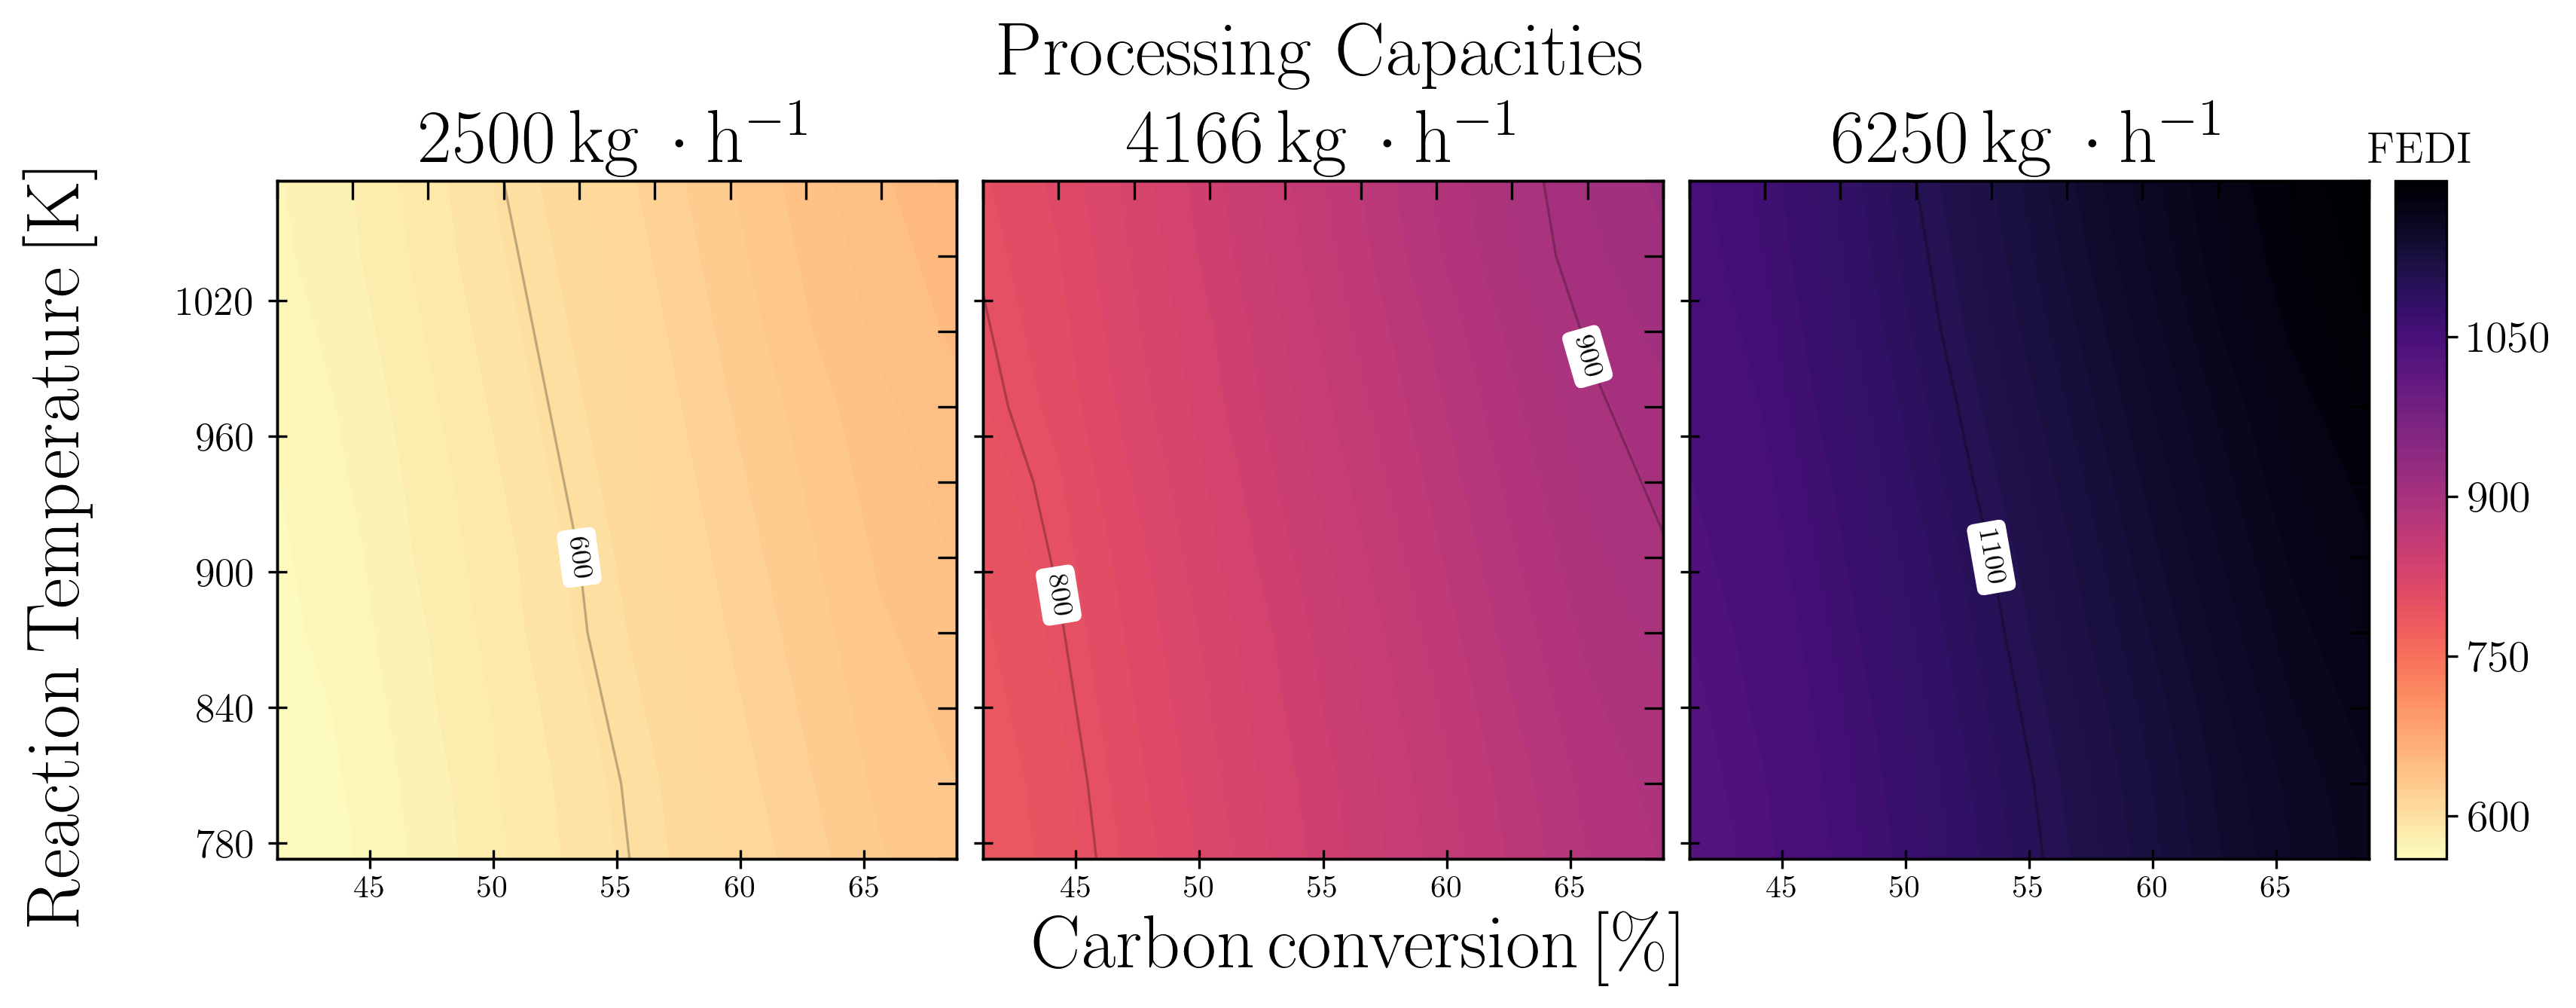

In [1]:
import pyrolysis
pyrolysis.plot_titer_carbonyield_temperature_FEDI('CarbonYield_Temperature_test.npz')

Different processing capacities

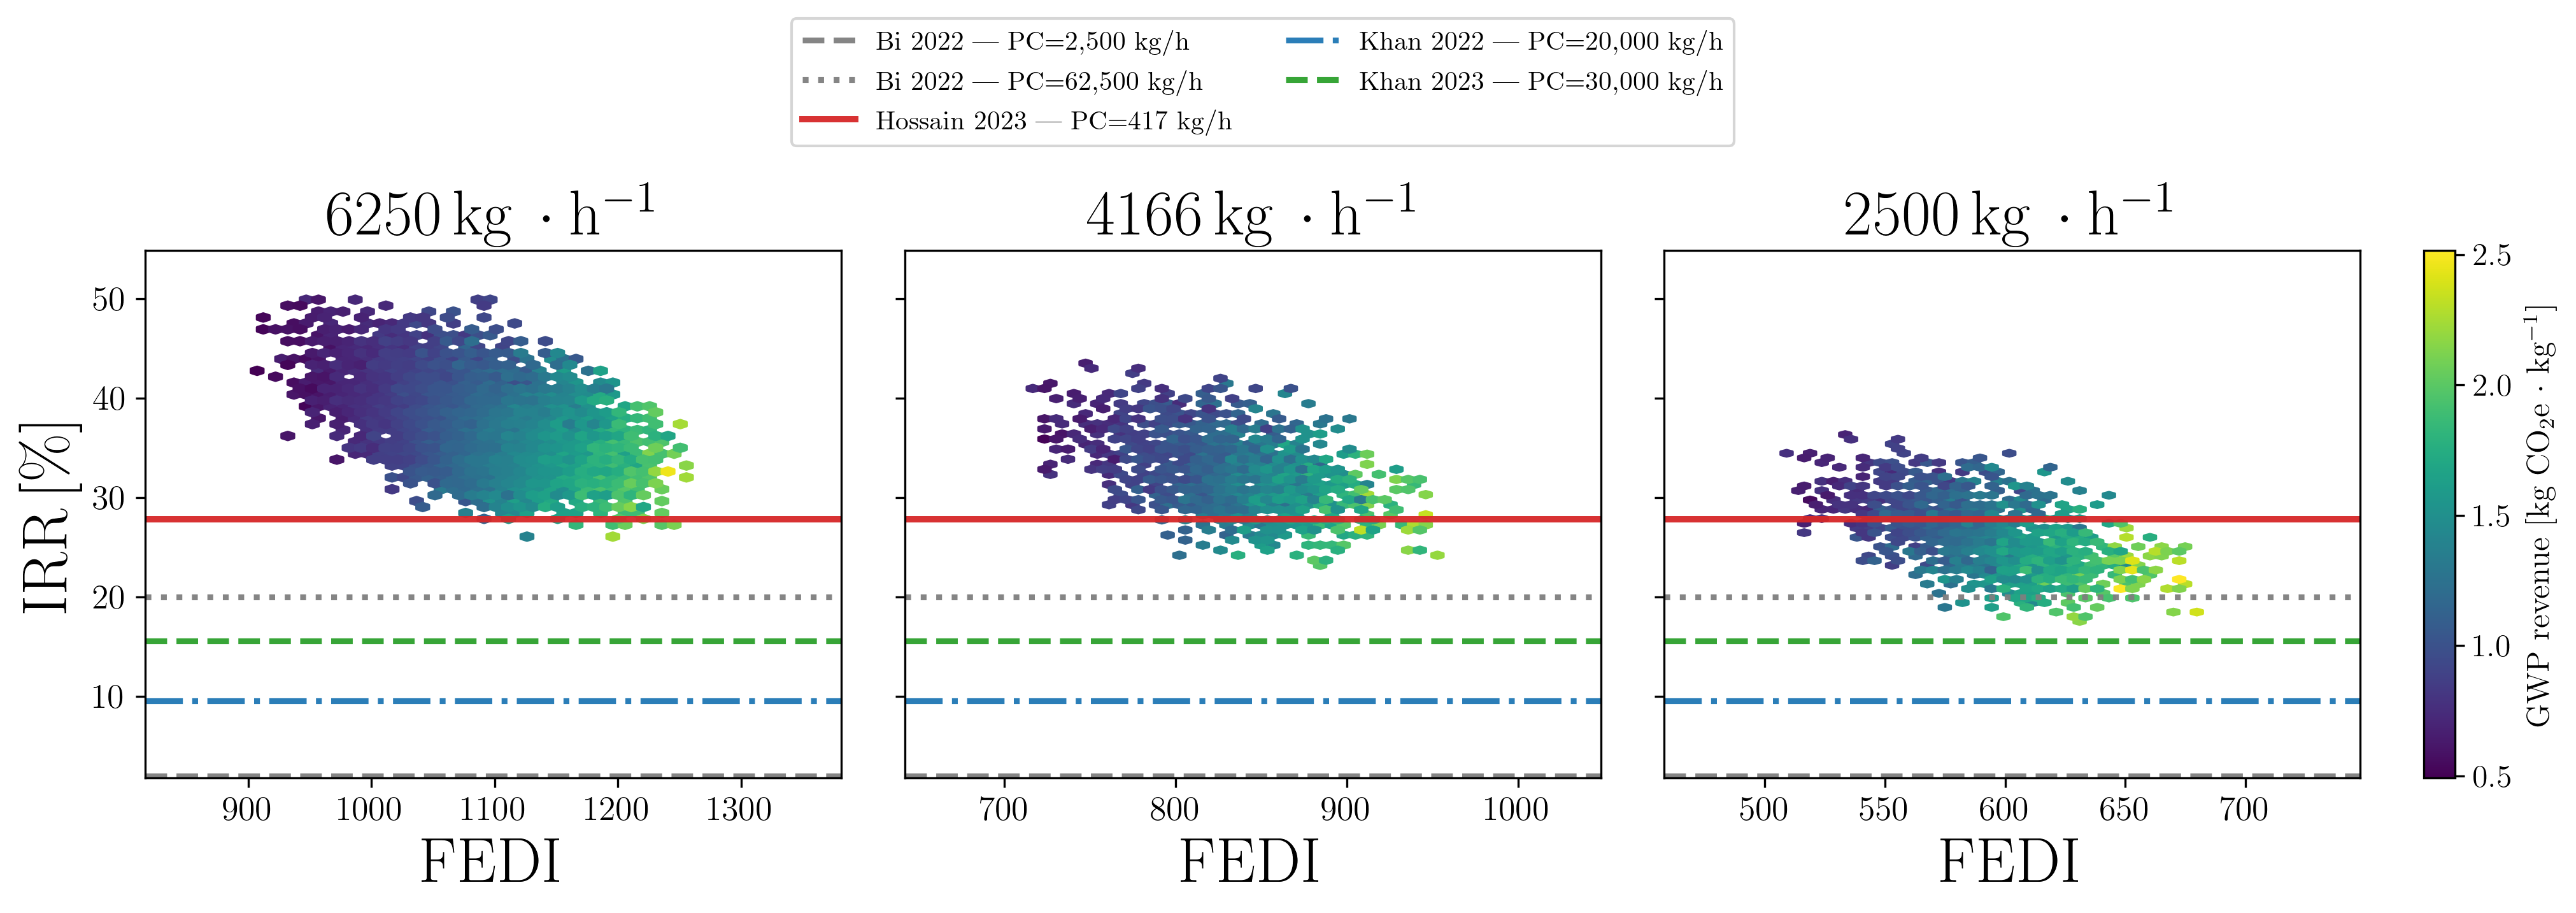

In [ ]:
files = ['test_scenario_run1.csv','test_scenario_run2.csv','test_scenario_run3.csv']
xlabel = r"$\mathrm{FEDI}$" 
ylabel = r"$\mathrm{IRR}\,[\%]$ " 
scenarios = [ "\n" + r"$6250\,\mathrm{kg}\,\cdot\mathrm{h}^{-1}$",
             "\n" + r"$4166\,\mathrm{kg}\,\cdot\mathrm{h}^{-1}$", 
            "\n" + r"$2500\,\mathrm{kg}\,\cdot\mathrm{h}^{-1}$"]

benchmarks = [
    # Bi 2022 (promedios de rangos):
    {"author": "Bi", "year": "2022", "pc": 2500,  "irr": 2.0,
     "color": "tab:gray", "linestyle": "--", "lw": 2.2},

    {"author": "Bi", "year": "2022", "pc": 62500, "irr": 20.0,
     "color": "tab:gray", "linestyle": ":", "lw": 2.2},

    # Hossain 2023
    {"author": "Hossain", "year": "2023", "pc": 416.67, "irr": 27.81,
     "color": "tab:red", "linestyle": "-", "lw": 2.4},

    # Khan 2022
    {"author": "Khan", "year": "2022", "pc": 20000, "irr": 9.55,
     "color": "tab:blue", "linestyle": "-.", "lw": 2.2},

    # Khan 2023
    {"author": "Khan", "year": "2023", "pc": 30000, "irr": 15.56,
     "color": "tab:green", "linestyle": "--", "lw": 2.2},
]

pyrolysis.plot_hexbin_gwp(files= files,
                        ylabel= ylabel,
                        xlabel= xlabel,
                        file_figure='Figure9.eps',
                        scenarios= scenarios, # , [r"PC$_{max}$", r"PC$_{mean}$", r"PC$_{min}$"],
                        benchmarks=benchmarks,
                        extend_limits_for_benchmarks=True,
                        show_benchmark_text=False  # si quieres texto afuera, pon True
                    )